# Price model: XGBoost vs a Bayesian hierarchical model

**Question.** Given a description of any Amazon listing, at any time and
regardless of how it was collected (title, category, brand, reviews, rating,
sales bin), how closely can we predict its price, and how honest is each model
about its uncertainty?

**Target:** `log(current_price)`, the shelf price shown on the listing. Not
`final_price` (after a clip-on coupon): coupons are temporary, so they are
neither an input nor part of the target (the two differ on 162 products).
Log because prices span $2.50 to $4,700 and errors are naturally
multiplicative ("off by 1.5x").

**Inputs are limited to what describes the listing itself** (user's call,
2026-09-25). Left out on purpose:
- *scrape time*: predictive in this data (R² +0.07) only because each scrape
  run collected different kinds of listings; meaningless for a new listing;
- *sponsored, coupon, in stock*: describe the moment of the scrape, not the
  product, and added nothing (they hurt on unseen brands) in an ablation.

**Rows:** the 5,830 distinct products with a price (`amazon_products_deduped.csv`).
Products with no price are almost all out of stock; they're not
predicted here (see the imputation evaluation in `HANDOFF.md`).

**Why two models.** XGBoost (gradient-boosted trees) is the standard strong
baseline for tabular prediction: flexible, fast, no distributional
assumptions. The Bayesian hierarchical model is linear but models the
grouping (category > brand > product family) explicitly, with partial pooling,
and returns a full predictive distribution. The comparison is less "who wins"
than "where does each win": point accuracy, interval calibration, and
brands the model has never seen.

In [1]:
import os
os.environ.setdefault('PYTENSOR_FLAGS', 'cxx=')  # PyTensor's C linker flags break on this macOS toolchain; nutpie compiles via numba anyway
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import pymc as pm
import arviz as az
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold

d = pd.read_csv('../data/amazon_products_deduped.csv')
d = d[d['current_price'].notna()].reset_index(drop=True)
y = np.log(d['current_price'].to_numpy())
print(f'{len(d)} priced products, {d.brand.nunique()} brands, {d.category.nunique()} categories, '
      f'{d.product_family.nunique()} families ({(d.product_family.map(d.product_family.value_counts()) > 1).sum()} products in multi-listing families)')

5830 priced products, 454 brands, 22 categories, 5175 families (1047 products in multi-listing families)


## Features (identical for both models)

- **Title embedding** (`thenlper/gte-base`, 768 dimensions), reduced to 64
  principal components. The title is where "what is this product" lives,
  which is most of what determines price. 64 components keep the Bayesian
  model small; XGBoost on all dimensions scored the same with the earlier
  model (R² 0.788 vs 0.784), so little is lost for it.
  *Model choice:* screened with XGBoost (`src/embedding_screen.py`, results in
  `data/embedding_screen.csv`, same features and folds as here):

  | embedding | size | family R² / within x2 | brand R² / within x2 |
  |---|---|---|---|
  | all-MiniLM-L6-v2 (used before) | 22M | 0.822 / 80.8% | 0.590 / 56.9% |
  | BAAI/bge-base-en-v1.5 | 110M | 0.829 / 82.1% | 0.617 / 58.2% |
  | intfloat/e5-base-v2 | 110M | 0.827 / 81.6% | 0.624 / 59.1% |
  | **thenlper/gte-base** | 110M | **0.832 / 81.9%** | **0.625 / 58.5%** |
  | BAAI/bge-large-en-v1.5 | 335M | 0.835 / 82.3% | 0.622 / 59.0% |

  The three base-size models tie (gaps under a point) and all beat MiniLM by
  ~1.5 points within x2 and ~0.03 R² on unseen brands, on every metric; the
  gain comes from size, not the training recipe. The large model adds under a
  point for 3x the embedding time (40 min vs 12 on a CPU). gte-base has the
  best average R² of the base models. Categories still use MiniLM.
- **Numeric:** log(1 + reviews), rating, log(1 + sales lower bound). Missing
  values (<1%) filled with 0 / the median rating. Sales matter most of the
  three; they are partly a *consequence* of price (cheap items sell more), which
  is fine for prediction but not a causal statement.
- **Text score** (added after the first comparison, see below): a ridge
  regression's price guess from the title's actual *words and numbers*.
- **Groups:** category, brand. XGBoost gets them as native categorical
  features; the Bayesian model gets them as partially pooled intercepts
  (plus product family, which XGBoost can't use for unseen families anyway).

The PCA is fit on all titles, including held-out ones. That uses no prices,
so it doesn't leak the target.

Not used: within-category price percentile (computed from the target itself).

In [2]:
E = (SentenceTransformer('thenlper/gte-base').float()  # ships float16; float32 for stable numbers
     .encode(d['Title'].tolist(), batch_size=64, normalize_embeddings=True, show_progress_bar=False))
Z = PCA(64, random_state=0).fit_transform(E)
num_cols = ['log_reviews', 'rating', 'log_sales']
num = np.column_stack([
    np.log1p(d['number_of_reviews'].fillna(0)), d['rating'].fillna(d['rating'].median()),
    np.log1p(d['bought_in_last_month'].fillna(0)),
]).astype(float)
X = np.column_stack([Z, num])
X = (X - X.mean(0)) / X.std(0)  # standardized, so one prior scale fits every coefficient
cat_codes, cats = pd.factorize(d['category'])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

## Evaluation: two grouped cross-validation splits

Near-duplicate listings (same product family) share their price almost
exactly (ICC of log price ~0.94), so a random split would let a model "predict" a
price by recognising the sibling listing. Both splits keep groups whole:

- **Family split** (`GroupKFold` by `product_family`, 5 folds): every held-out
  product is from a family the model hasn't seen, but its brand usually has been.
  This is the realistic "new listing" case.
- **Brand split** (`GroupKFold` by `brand`): every held-out product's brand is
  unseen. Tests how each model handles a group it knows nothing about.

**Metrics** (on log price, out-of-fold):
- **RMSE** and **R²**: point accuracy.
- **median x-error**: exp(median |error|); 1.5 means the typical prediction
  is off by a factor of 1.5.
- **within x2 / x3**: share of products whose prediction is within a factor
  of 2 (or 3) of the true price. The "rough estimate" view.
- **band accuracy**: share predicted in the right price band (<$25, $25-100,
  $100-500, $500+).
- **80% interval coverage**: share of true prices inside the model's 80%
  interval. Should be ~0.80; lower means overconfident.
- **interval width**: median ratio of the interval's top to bottom (x-fold).
  Narrower is better *only if* coverage holds.

In [3]:
SPLIT_COL = {'family': 'product_family', 'brand': 'brand'}
splits = {name: list(GroupKFold(5, shuffle=True, random_state=0).split(d, groups=d[col]))
          for name, col in SPLIT_COL.items()}

BANDS, BAND_NAMES = [0, 25, 100, 500, np.inf], ['<$25', '$25-100', '$100-500', '$500+']
band = lambda logp: pd.cut(np.exp(logp), BANDS, labels=False)

def metrics(y, m, lo=None, hi=None):
    e = y - m
    out = {'RMSE': np.sqrt((e ** 2).mean()), 'R²': 1 - (e ** 2).sum() / ((y - y.mean()) ** 2).sum(),
           'median x-error': np.exp(np.median(np.abs(e)))}
    out.update({'within x2': (np.abs(e) <= np.log(2)).mean(), 'within x3': (np.abs(e) <= np.log(3)).mean(),
                'band accuracy': (band(y) == band(m)).mean()})
    if lo is not None:
        out.update({'80% coverage': ((y >= lo) & (y <= hi)).mean(), 'interval width (x)': np.exp(np.median(hi - lo))})
    return out

oof = {}  # (model, split) -> (point, lo, hi)

## Text score: the title's words, condensed into one number

The first version of this comparison missed expensive devices whose price
depends on the exact model: an RTX 5080 ($1,099) predicted at $272, a Galaxy
Tab S10+ ($881) at $260, a Canon EOS R6 Mark II ($2,299) at $468. The
embedding knows "graphics card" or "camera", but it's weak on model numbers
("5080" vs "3050", "R6" vs "R50").

(We also tested the obvious alternative, a device-vs-accessory flag: no gain,
R² 0.784 -> 0.782, because the embedding already tells "iPad case" from "iPad".)

**TF-IDF** turns each title into weights on its words and two-word phrases
(`rtx`, `5080`, `rtx 5080`, `tab s10`...; 2+ titles each), rarer words
weighing more. A **ridge regression** on those weights (plus the full
embedding and category) learns a price effect per word; its prediction is the
**text score**, one number per product, given to both models as a feature.
Trees handle tens of thousands of sparse word columns badly and ridge handles
them well, so ridge condenses them and the main models use the result
(this is called *stacking*).

**No leakage.** A training product's text score must come from a ridge that
never saw its price, or the score would contain the answer. So within each
outer fold, training rows get scores from an inner 5-fold split (grouped the
same way as the outer split: by family, or by brand), and test rows get
scores from a ridge fit on the whole training fold.

In [4]:
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
W = sp.hstack([
    TfidfVectorizer(token_pattern=r'[a-z0-9]+', ngram_range=(1, 2), min_df=2, sublinear_tf=True).fit_transform(d['Title'].str.lower()),
    sp.csr_matrix(E), sp.csr_matrix(pd.get_dummies(d['category']).to_numpy(float)),
]).tocsr()
print(f'{W.shape[1]:,} text columns')

def text_score(tr, te, col):
    out = np.full(len(d), np.nan)
    for itr, ite in GroupKFold(5, shuffle=True, random_state=1).split(tr, groups=d[col].iloc[tr]):
        out[tr[ite]] = Ridge(1.0).fit(W[tr[itr]], y[tr[itr]]).predict(W[tr[ite]])
    out[te] = Ridge(1.0).fit(W[tr], y[tr]).predict(W[te])
    return out

TS = {split: [text_score(tr, te, SPLIT_COL[split]) for tr, te in folds] for split, folds in splits.items()}
for split, folds in splits.items():  # the text score alone, as a model
    p = np.zeros(len(d))
    for (tr, te), ts in zip(folds, TS[split]):
        p[te] = ts[te]
    oof['text score alone', split] = (p, None, None)

24,064 text columns


## Baseline: ridge regression

The earlier imputation check: linear, full 384-d embedding + category
one-hot + numeric features, no brand. Point predictions only.

In [5]:
R = np.column_stack([E, pd.get_dummies(d['category']).to_numpy(float), num])
for split, folds in splits.items():
    p = np.zeros(len(d))
    for tr, te in folds:
        p[te] = Ridge(1.0).fit(R[tr], y[tr]).predict(R[te])
    oof['ridge', split] = (p, None, None)

## XGBoost

Point model: squared error on log price. Intervals: a second model with the
quantile loss at the 10th and 90th percentiles. Settings are standard
(800 trees, learning rate 0.03, depth 6, row/column subsampling), not tuned
per split. A brand not seen in training is passed as missing.

Raw quantile regression is known to under-cover on new data. So there's also
a **conformal** version (conformalized quantile regression): hold out 20% of the
training families, measure how far outside the quantile band their true
prices fall, and widen the band by the 80th percentile of that miss. That
guarantees ~80% coverage for new products drawn like the calibration ones,
and gives XGBoost a fair shot at honest intervals.

In [6]:
XGB = dict(n_estimators=800, learning_rate=0.03, max_depth=6, subsample=0.8, colsample_bytree=0.5,
           min_child_weight=3, enable_categorical=True, tree_method='hist', max_cat_to_onehot=1, random_state=0)
from sklearn.model_selection import GroupShuffleSplit
for split, folds in splits.items():
    p, lo, hi, clo, chi = (np.zeros(len(d)) for _ in range(5))
    for (tr, te), ts in zip(folds, TS[split]):
        T = pd.DataFrame(X, columns=[f'x{i}' for i in range(X.shape[1])])
        T['text_score'] = ts
        T['category'] = d['category'].astype('category')
        seen = sorted(set(d['brand'].iloc[tr]))
        T['brand'] = pd.Categorical(d['brand'].where(d['brand'].isin(seen)), categories=seen)
        p[te] = xgb.XGBRegressor(**XGB).fit(T.iloc[tr], y[tr]).predict(T.iloc[te])
        q = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=np.array([.1, .9]), **XGB)
        lo[te], hi[te] = q.fit(T.iloc[tr], y[tr]).predict(T.iloc[te]).T
        # conformal: refit the quantile model on 80% of the training groups, calibrate on the rest
        fit_i, cal_i = next(GroupShuffleSplit(1, test_size=0.2, random_state=0).split(tr, groups=d[SPLIT_COL[split]].iloc[tr]))
        fit_i, cal_i = tr[fit_i], tr[cal_i]
        qc = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=np.array([.1, .9]), **XGB).fit(T.iloc[fit_i], y[fit_i])
        cl, ch = qc.predict(T.iloc[cal_i]).T
        score = np.maximum(cl - y[cal_i], y[cal_i] - ch)
        qhat = np.quantile(score, min(1, np.ceil(0.8 * (len(cal_i) + 1)) / len(cal_i)))
        tl, th = qc.predict(T.iloc[te]).T
        clo[te], chi[te] = tl - qhat, th + qhat
    oof['xgboost', split] = (p, lo, hi)
    oof['xgboost + conformal', split] = (p, clo, chi)

## Bayesian hierarchical model

$$
\log(\text{price}_i) \sim \text{StudentT}\big(\nu,\ \mu_i,\ \sigma_i\big),\qquad
\mu_i = b_0 + a^{\text{cat}}_{c[i]} + a^{\text{brand}}_{b[i]} + a^{\text{family}}_{f[i]} + x_i^\top \beta
$$

$$
a^{\text{cat}} \sim N(0, s_{\text{cat}}),\quad
a^{\text{brand}}_b \sim N\big(w_b^\top \eta,\ s_{\text{brand}}\, e^{\gamma\,\ell_b}\big),\quad
a^{\text{family}} \sim N(0, s_{\text{family}}),\quad
\sigma_i = \sigma\, e^{\delta\,\ell_{b[i]}},\quad \beta \sim N(0, 0.3)
$$

where $\ell_b = \log(1 + N_b) - \overline{\log(1+N)}$ is the (centered) log of how many
listings brand $b$ has in the catalog, and $w_b$ is the brand's popularity profile (below).

- **Partial pooling.** Each brand gets its own price level, but brands with
  few products are pulled toward the average, in proportion to how little
  data they have. The model learns *how much* to pool (`s_brand`) from the data.
- **Student-t errors** instead of normal: a few listings are wildly off
  (bundles, mislabelled pack sizes); heavy tails stop them from dragging the fit.
  $\nu$ is learned (~5, i.e. clearly heavy-tailed).
- **Non-centered parameterization** ($a = s \cdot z$, $z \sim N(0,1)$): the
  standard fix that lets NUTS sample hierarchical models without divergences.
- **Singleton families.** Most families have one product, and for those the
  family effect is indistinguishable from the noise. Giving them their own
  parameter made the sampler mix poorly (R-hat up to 1.09). Instead, only
  families with 2+ training members get a family effect; for singletons it is
  integrated out by widening their noise to $\sqrt{\sigma^2 + s_{\text{family}}^2}$.
  Same model, 4,600 fewer parameters, R-hat <= ~1.02.
- **Spreads that depend on brand size** ($\gamma$, $\delta$). The first version
  used one brand SD and one noise SD for everyone, and its 80% intervals
  covered only 68% of products from brands with 1-2 listings. Diagnosis: the
  text score contains the brand's *words*, so for a big brand the word model
  has already priced the brand and little brand effect is left over, while for
  a tiny brand the word model has never seen the name. One shared brand SD
  (0.25 with the text score, down from 0.57 without it) was right for big
  brands and too small for tiny ones. Letting both SDs scale with brand size
  fixes it (fitted on the family split, with the text score): $\gamma \approx -0.35$ (the leftover brand spread shrinks
  quickly as brands grow), $\delta \approx -0.08$ (a smaller effect on the
  per-product noise). Tiny-brand coverage 68% -> 76% (the remaining gap is
  ~1.5 standard errors on 271 products), others unchanged, brand split still
  calibrated (79 to 80% in every brand-size bucket) and narrower.
  $N_b$ is a listing count; it uses no prices, so it doesn't leak the target,
  and it is known for a brand never seen in training.
- **Brand popularity sets each brand's starting point** ($\eta$, user's idea).
  Instead of every brand starting at "average" (1x), a brand's multiplier is
  centered on $w_b^\top\eta$, where $w_b$ = the brand's average log reviews,
  log sales and rating over all its listings (standardized across brands; no
  prices used). The brand's own prices still decide where a well-sampled brand
  ends up; the starting point matters for brands with few products and for
  brands never seen in training, which start there instead of at 1x. Scrape
  counts are *not* used (they don't measure popularity: more-scraped products
  sell less, Spearman -0.26). Caveats: for a one-product brand $w_b$ is just
  that product's own numbers, which are already inputs; and a single listing
  from an unknown brand gets little from it. The gain is on unseen brands
  (within x2: 62.0% -> 63.0% in testing); the value is the finding itself (see
  $\eta$ in the fit on all products).
- **Priors** are weakly informative on the standardized features: effects of
  more than ~1 on log price per standard deviation are unlikely a priori.

**Predicting a held-out product.** For each posterior draw: use the brand's
fitted effect if the brand was in training; otherwise draw a fresh brand
effect from $N(0, s_{\text{brand}} e^{\gamma \ell_b})$ (wider for small brands). Held-out families are always new, so
their effect is drawn from $N(0, s_{\text{family}})$. Then add Student-t
noise with the product's $\sigma_i$. The point prediction is the median of those predictive draws; the
80% interval is their 10th to 90th percentile. This is how the model's
uncertainty automatically widens for unseen brands.

Sampler: NUTS via nutpie, 4 chains x (2,000 tune + 1,000 draws).

In [7]:
N_BRAND = d['brand'].value_counts()                   # listings per brand in the catalog (no prices used)
LOG_N_MEAN = np.log1p(d['brand'].map(N_BRAND)).mean()
ell = lambda b: np.log1p(pd.Series(b).map(N_BRAND).to_numpy()) - LOG_N_MEAN  # centered, so s_brand and
LOG_N = ell(d['brand'])                                                          # sigma are SDs at a typical size
# brand popularity profile: mean over the brand's listings, standardized across brands (no prices)
W_BRAND = (pd.DataFrame({'log_reviews': num[:, 0], 'rating': num[:, 1], 'log_sales': num[:, 2], 'brand': d['brand']})
             .groupby('brand').mean())
W_BRAND = (W_BRAND - W_BRAND.mean()) / W_BRAND.std()

def fit(tr, X):
    b_idx, brands = pd.factorize(d['brand'].iloc[tr])
    brand_log_n = ell(brands)
    fam = d['product_family'].iloc[tr]
    multi = (fam.map(fam.value_counts()) > 1).to_numpy()
    fams = fam[multi].unique()
    f_idx = np.maximum(pd.Index(fams).get_indexer(fam), 0)
    with pm.Model() as model:
        b0 = pm.Normal('b0', y[tr].mean(), 1)
        beta = pm.Normal('beta', 0, 0.3, shape=X.shape[1])
        s_cat, s_brand, s_fam = (pm.HalfNormal(n, 1) for n in ('s_cat', 's_brand', 's_family'))
        a_cat = pm.Deterministic('a_cat', s_cat * pm.Normal('z_cat', 0, 1, shape=len(cats)))
        gamma = pm.Normal('gamma', 0, 0.5)          # brand SD vs brand size
        delta = pm.Normal('delta', 0, 0.5)          # noise SD vs brand size
        eta = pm.Normal('eta', 0, 0.5, shape=W_BRAND.shape[1])  # brand popularity -> brand price level
        sd_brand = s_brand * pm.math.exp(gamma * brand_log_n)
        a_brand = pm.Deterministic('a_brand', pm.math.dot(W_BRAND.loc[brands].to_numpy(), eta)
                                   + sd_brand * pm.Normal('z_brand', 0, 1, shape=len(brands)))
        a_fam = pm.Deterministic('a_family', s_fam * pm.Normal('z_family', 0, 1, shape=len(fams)))
        sigma = pm.HalfNormal('sigma', 1) * pm.math.exp(delta * LOG_N[tr])
        nu = pm.Gamma('nu', 2, 0.1)
        mu = b0 + a_cat[cat_codes[tr]] + a_brand[b_idx] + pm.math.dot(X[tr], beta)
        mu = mu + pm.math.where(multi, a_fam[f_idx], 0)
        scale = pm.math.where(multi, sigma, pm.math.sqrt(sigma ** 2 + s_fam ** 2))
        pm.StudentT('log_price', nu=nu, mu=mu, sigma=scale, observed=y[tr])
        idata = pm.sample(1000, tune=2000, chains=4, nuts_sampler='nutpie', random_seed=0, progressbar=False)
    return idata, brands

def predict(idata, brands, te, X, seed=0):
    po = idata.posterior.to_dataset().stack(s=('chain', 'draw'))
    g = lambda v: po[v].to_numpy()
    rng = np.random.default_rng(seed)
    n = po.sizes['s']
    bi = pd.Index(brands).get_indexer(d['brand'].iloc[te])
    new_brand = (W_BRAND.loc[d['brand'].iloc[te]].to_numpy() @ g('eta')        # unseen brand: start from its popularity,
                 + rng.standard_normal((len(te), n))                            # fresh draw at its size
                 * g('s_brand') * np.exp(g('gamma') * LOG_N[te][:, None]))
    a_brand = np.where(bi[:, None] >= 0, g('a_brand')[np.maximum(bi, 0)], new_brand)
    a_fam = rng.standard_normal((len(te), n)) * g('s_family')              # held-out families are always new
    mu = g('b0') + g('a_cat')[cat_codes[te]] + a_brand + a_fam + X[te] @ g('beta')
    sigma = g('sigma') * np.exp(g('delta') * LOG_N[te][:, None])
    draws = mu + sigma * rng.standard_t(g('nu'), (len(te), n))
    return np.median(draws, 1), *np.quantile(draws, [.1, .9, .25, .75], 1)  # median, 80% and 50% intervals

diag, oof50 = [], {}  # oof50[split] = (lo, hi) of the 50% interval
for split, folds in splits.items():
    p, lo, hi, lo50, hi50 = (np.zeros(len(d)) for _ in range(5))
    for k, ((tr, te), ts) in enumerate(zip(folds, TS[split])):
        Xf = np.column_stack([X, (ts - ts[tr].mean()) / ts[tr].std()])  # + standardized text score
        idata, brands = fit(tr, Xf)
        p[te], lo[te], hi[te], lo50[te], hi50[te] = predict(idata, brands, te, Xf)
        s = az.summary(idata, var_names=['~a_'], filter_vars='like')
        diag.append({'split': split, 'fold': k, 'max R-hat': s['r_hat'].max(), 'min ESS': s['ess_bulk'].min(),
                     'divergences': int(idata.sample_stats['diverging'].sum())})
    oof['bayes', split] = (p, lo, hi)
    oof50[split] = (lo50, hi50)
pd.DataFrame(diag).round(3)

NUTS[nutpie]: [b0, beta, s_cat, s_brand, s_family, z_cat, gamma, delta, eta, z_brand, z_family, sigma, nu]


/Users/brianwang/Downloads/datathon/.venv/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py:1004: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(


NUTS[nutpie]: [b0, beta, s_cat, s_brand, s_family, z_cat, gamma, delta, eta, z_brand, z_family, sigma, nu]


/Users/brianwang/Downloads/datathon/.venv/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py:1004: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(


NUTS[nutpie]: [b0, beta, s_cat, s_brand, s_family, z_cat, gamma, delta, eta, z_brand, z_family, sigma, nu]


...

NUTS[nutpie]: [b0, beta, s_cat, s_brand, s_family, z_cat, gamma, delta, eta, z_brand, z_family, sigma, nu]


/Users/brianwang/Downloads/datathon/.venv/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py:1004: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(


NUTS[nutpie]: [b0, beta, s_cat, s_brand, s_family, z_cat, gamma, delta, eta, z_brand, z_family, sigma, nu]


/Users/brianwang/Downloads/datathon/.venv/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py:1004: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(


,split,fold,max R-hat,min ESS,divergences
0,family,0,1.007,591.821,0
1,family,1,1.008,633.301,0
2,family,2,1.007,640.304,0
3,family,3,1.008,628.168,0
4,family,4,1.008,527.323,0
5,brand,0,1.008,662.856,0
6,brand,1,1.008,710.685,0
7,brand,2,1.007,748.959,0
8,brand,3,1.006,649.411,0
9,brand,4,1.007,532.989,0


Convergence check: R-hat near 1 (chains agree), effective sample size in
the hundreds, and zero divergences on every fold: the posterior draws can
be trusted.

## Results

In [8]:
res = pd.DataFrame({(split, model): metrics(y, *oof[model, split]) for model, split in oof}).T
res.index.names = ['split', 'model']
res.sort_index().round(3)

RMSE     R²  median x-error  within x2  \
split  model                                                          
brand  bayes                0.745  0.684           1.631      0.657   
       ridge                0.781  0.653           1.694      0.622   
       text score alone     0.789  0.645           1.666      0.634   
       xgboost              0.811  0.626           1.773      0.592   
       xgboost + conformal  0.811  0.626           1.773      0.592   
family bayes                0.570  0.815           1.413      0.797   
       ridge                0.702  0.719           1.582      0.682   
       text score alone     0.621  0.780           1.459      0.767   
       xgboost              0.544  0.832           1.394      0.817   
       xgboost + conformal  0.544  0.832           1.394      0.817   

                            within x3  band accuracy  80% coverage  \
split  model                                                         
brand  bayes                    0.862          0.623         0.797   
       ridge                    0.840          0.607           NaN   
       text score alone         0.842          0.598           NaN   
       xgboost                  0.824          0.551         0.713   
       xgboost + conformal      0.824          0.551         0.822   
family bayes                    0.941          0.723         0.811   
       ridge                    0.884          0.646           NaN   
       text score alone         0.923          0.690           NaN   
       xgboost                  0.947          0.738         0.624   
       xgboost + conformal      0.947          0.738         0.808   

                            interval width (x)  
split  model                                    
brand  bayes                             6.665  
       ridge                               NaN  
       text score alone                    NaN  
       xgboost                           6.436  
       xgboost + conformal              10.295  
family bayes                             4.001  
       ridge                               NaN  
       text score alone                    NaN  
       xgboost                           2.609  
       xgboost + conformal               4.234

**Point accuracy.** On new listings from known brands (family split) the two
models are close: XGBoost R² 0.83 (typical error x1.39, 82% of products within
x2), the Bayesian model 0.82 (x1.41, 80%). Both beat the text score on its own
(0.78) and the embedding-only ridge (0.72), so the main models add real value
on top of the word model. The switch from MiniLM to the gte-base embedding
(see Features) added ~0.01 R² here (XGBoost 0.820 -> 0.832, Bayesian 0.803 ->
0.815). The text score was the largest single improvement
(XGBoost 0.784 -> 0.821, Bayesian 0.709 -> 0.805 in the earlier input set); the
switch to listing-only inputs cost almost nothing (XGBoost 0.821 -> 0.820,
Bayesian 0.805 -> 0.803).

On **unseen brands** (brand split) the Bayesian model is best: R² 0.68 vs 0.65
for the text score alone and ridge, 0.63 for XGBoost; 66% vs 59% within
x2 for XGBoost (brand popularity added +0.01 R² and +1 point here; gte-base
added +0.04 R², 63% -> 66%, more than for XGBoost because the Bayesian model
leans on the text score, which gained most from the better embedding). XGBoost sees an unseen brand as a missing value, while the
Bayesian model falls back on the fitted spread of brands. (Dropping the
sponsored/coupon/stock flags *helped* XGBoost here: 0.56 -> 0.59.)

**Intervals.** Raw XGBoost quantiles are overconfident: the "80%" interval
holds the true price only 62% of the time. The Bayesian model is calibrated
out of the box (81% / 80%). Conformal calibration fixes XGBoost
(81% / 82%), but the Bayesian intervals are narrower: x4.0 vs x4.2 on known
brands and **x6.7 vs x10.3 on unseen brands**. The
Bayesian model knows *how much* brands vary, and how that depends on brand
size, and widens by exactly that; conformal applies one global correction.

## Price-band confusion matrices (family split)

Each row is the true price band; each cell is the share of that band's
products predicted into each band (rows sum to 100%). The diagonal is
correct; one cell off is "right ballpark".

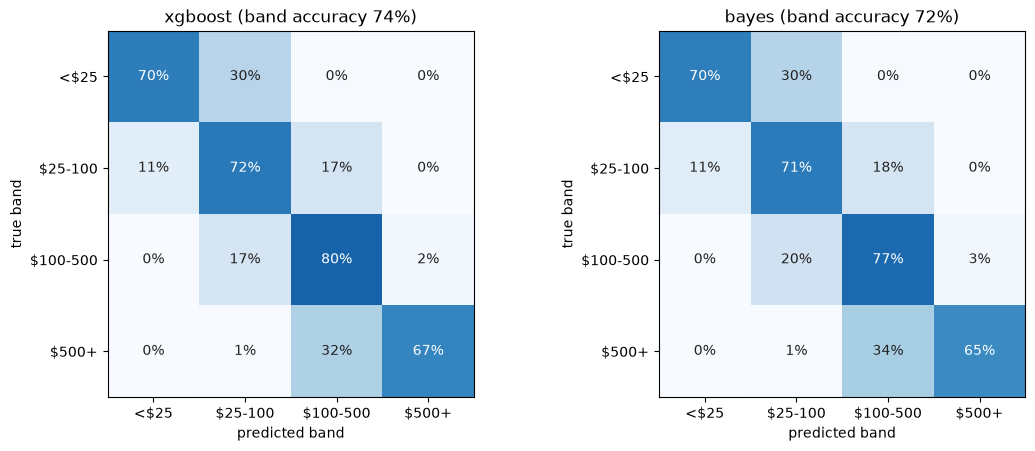

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
for ax, model in zip(axes, ['xgboost', 'bayes']):
    cm = pd.crosstab(pd.Categorical(band(y), range(4)), pd.Categorical(band(oof[model, 'family'][0]), range(4)),
                     normalize='index', dropna=False).to_numpy()
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{cm[i, j]:.0%}', ha='center', va='center', color='white' if cm[i, j] > 0.5 else '#222')
    ax.set_xticks(range(4), BAND_NAMES)
    ax.set_yticks(range(4), BAND_NAMES)
    ax.set_xlabel('predicted band')
    ax.set_ylabel('true band')
    ax.set_title(f"{model} (band accuracy {metrics(y, oof[model, 'family'][0])['band accuracy']:.0%})")
plt.show()

## Where does each model win? Error and coverage by brand size (family split)

Brand size = number of products that brand has in the data. Small brands are
where partial pooling should matter most.

In [10]:
size = d['brand'].map(d['brand'].value_counts())
bucket = pd.cut(size, [0, 2, 10, 50, 10_000], labels=['1-2', '3-10', '11-50', '51+'])
rows = []
for model in ['xgboost', 'xgboost + conformal', 'bayes']:
    p, lo, hi = oof[model, 'family']
    for b in bucket.cat.categories:
        m = (bucket == b).to_numpy()
        rows.append({'model': model, 'brand size': b, 'products': m.sum(),
                     **{k: v for k, v in metrics(y[m], p[m], lo[m], hi[m]).items() if k != 'R²'}})
pd.DataFrame(rows).set_index(['brand size', 'model']).sort_index().round(3)

products   RMSE  median x-error  within x2  \
brand size model                                                             
1-2        bayes                     252  0.807           1.708      0.611   
           xgboost                   252  0.780           1.750      0.611   
           xgboost + conformal       252  0.780           1.750      0.611   
11-50      bayes                    2122  0.575           1.431      0.787   
           xgboost                  2122  0.555           1.422      0.810   
           xgboost + conformal      2122  0.555           1.422      0.810   
3-10       bayes                     762  0.616           1.466      0.768   
           xgboost                   762  0.605           1.475      0.778   
           xgboost + conformal       762  0.605           1.475      0.778   
51+        bayes                    2694  0.524           1.373      0.831   
           xgboost                  2694  0.486           1.339      0.852   
           xgboost + conformal      2694  0.486           1.339      0.852   

                                within x3  band accuracy  80% coverage  \
brand size model                                                         
1-2        bayes                    0.825          0.540         0.770   
           xgboost                  0.817          0.552         0.615   
           xgboost + conformal      0.817          0.552         0.798   
11-50      bayes                    0.936          0.719         0.801   
           xgboost                  0.946          0.731         0.604   
           xgboost + conformal      0.946          0.731         0.788   
3-10       bayes                    0.921          0.681         0.816   
           xgboost                  0.925          0.689         0.509   
           xgboost + conformal      0.925          0.689         0.730   
51+        bayes                    0.961          0.756         0.821   
           xgboost                  0.965          0.775         0.673   
           xgboost + conformal      0.965          0.775         0.846   

                                interval width (x)  
brand size model                                    
1-2        bayes                             6.387  
           xgboost                           5.411  
           xgboost + conformal               9.467  
11-50      bayes                             4.145  
           xgboost                           2.617  
           xgboost + conformal               4.164  
3-10       bayes                             4.694  
           xgboost                           2.239  
           xgboost + conformal               3.730  
51+        bayes                             3.806  
           xgboost                           2.634  
           xgboost + conformal               4.287

- **Point error:** XGBoost is slightly better for brands with 3+ products;
  for the smallest brands (1-2 products) the two are level (RMSE 0.78 vs
  0.81, typical error x1.75 vs x1.71, 61% within x2 both).
- **Coverage by brand size.** Bayesian: 77% / 82% / 80% / 82% from the
  smallest to the largest brands. Before the brand-size terms were added
  (see the model section) the smallest brands were at 68%; the remaining gap
  is ~1.2 standard errors on 252 products. Conformal XGBoost: 80% / 73% /
  79% / 85%, and its intervals are much wider for tiny brands (x9.5 vs x6.4).

So: **XGBoost for the best single guess on established brands; the Bayesian
model for unseen brands, narrower calibrated intervals, and for explaining
the price structure** (below).

## How wide are the Bayesian intervals, and for whom? (50% and 80%)

The "x4" 80% width above is a median over all products. Two ways to make it
concrete: a **50% interval** (the "likely range": the price should fall inside
it half the time) next to the 80% one, and the widths broken down by brand
size and by *predicted* price band (what a user would see). The `$100 guess`
columns translate each median width into a range around a $100 prediction
(approximate: the intervals are close to symmetric in log price).

In [11]:
rows = []
for split in ['family', 'brand']:
    p, lo, hi = oof['bayes', split]
    lo50, hi50 = oof50[split]
    groups = {'all products': np.ones(len(d), bool)}
    groups |= {f'brand size {b}': (bucket == b).to_numpy() for b in bucket.cat.categories}
    groups |= {f'predicted {n}': band(p) == k for k, n in enumerate(BAND_NAMES)}
    for g, m in groups.items():
        w50, w80 = np.exp(np.median(hi50[m] - lo50[m])), np.exp(np.median(hi[m] - lo[m]))
        rows.append({'split': split, 'group': g, 'products': m.sum(),
                     '50% coverage': ((y[m] >= lo50[m]) & (y[m] <= hi50[m])).mean(), '50% width (x)': w50,
                     '$100 guess, 50%': f'${100 / w50 ** .5:.0f}-{100 * w50 ** .5:.0f}',
                     '80% coverage': ((y[m] >= lo[m]) & (y[m] <= hi[m])).mean(), '80% width (x)': w80,
                     '$100 guess, 80%': f'${100 / w80 ** .5:.0f}-{100 * w80 ** .5:.0f}'})
pd.DataFrame(rows).set_index(['split', 'group']).round(2)

products  50% coverage  50% width (x)  \
split  group                                                       
family all products            5830          0.53           2.07   
       brand size 1-2           252          0.47           2.65   
       brand size 3-10          762          0.53           2.25   
       brand size 11-50        2122          0.52           2.11   
       brand size 51+          2694          0.54           2.02   
       predicted <$25          1178          0.55           2.06   
       predicted $25-100       2221          0.50           2.08   
       predicted $100-500      2066          0.54           2.07   
       predicted $500+          365          0.58           2.04   
brand  all products            5830          0.51           2.71   
       brand size 1-2           252          0.56           2.98   
       brand size 3-10          762          0.51           2.83   
       brand size 11-50        2122          0.51           2.73   
       brand size 51+          2694          0.51           2.62   
       predicted <$25           974          0.61           2.71   
       predicted $25-100       2685          0.46           2.71   
       predicted $100-500      1893          0.53           2.70   
       predicted $500+          278          0.56           2.65   

                          $100 guess, 50%  80% coverage  80% width (x)  \
split  group                                                             
family all products               $70-144          0.81           4.00   
       brand size 1-2             $61-163          0.77           6.39   
       brand size 3-10            $67-150          0.82           4.69   
       brand size 11-50           $69-145          0.80           4.14   
       brand size 51+             $70-142          0.82           3.81   
       predicted <$25             $70-143          0.84           3.94   
       predicted $25-100          $69-144          0.78           4.05   
       predicted $100-500         $69-144          0.82           4.02   
       predicted $500+            $70-143          0.83           3.87   
brand  all products               $61-164          0.80           6.66   
       brand size 1-2             $58-173          0.79           7.97   
       brand size 3-10            $59-168          0.82           7.23   
       brand size 11-50           $60-165          0.81           6.78   
       brand size 51+             $62-162          0.79           6.24   
       predicted <$25             $61-165          0.86           6.68   
       predicted $25-100          $61-165          0.77           6.68   
       predicted $100-500         $61-164          0.80           6.66   
       predicted $500+            $61-163          0.82           6.44   

                          $100 guess, 80%  
split  group                               
family all products               $50-200  
       brand size 1-2             $40-253  
       brand size 3-10            $46-217  
       brand size 11-50           $49-204  
       brand size 51+             $51-195  
       predicted <$25             $50-198  
       predicted $25-100          $50-201  
       predicted $100-500         $50-201  
       predicted $500+            $51-197  
brand  all products               $39-258  
       brand size 1-2             $35-282  
       brand size 3-10            $37-269  
       brand size 11-50           $38-260  
       brand size 51+             $40-250  
       predicted <$25             $39-258  
       predicted $25-100          $39-258  
       predicted $100-500         $39-258  
       predicted $500+            $39-254

In [12]:
# a few random products (family split): what a prediction looks like in dollars
p, lo, hi = oof['bayes', 'family']
lo50, hi50 = oof50['family']
ex = d.sample(8, random_state=3).index.to_numpy()
usd = lambda a, b: [f'${np.exp(u):,.0f}-{np.exp(v):,.0f}' for u, v in zip(a, b)]
pd.DataFrame({'title': d['Title'].iloc[ex].str[:70], 'brand': d['brand'].iloc[ex], 'price': np.exp(y[ex]).round(2),
              'predicted': np.exp(p[ex]).round(0), 'likely (50%)': usd(lo50[ex], hi50[ex]),
              'plausible (80%)': usd(lo[ex], hi[ex])})

,title,brand,price,predicted,likely (50%),plausible (80%)
1294,Energizer Alkaline Power AAA Batteries (20 Pac...,Energizer,15.05,9.0,$6-12,$4-17
3201,SteelSeries New Apex 9 Mini – HotSwap Optical ...,Steelseries,98.15,54.0,$37-78,$27-111
590,Belkin Quick Charge Wireless Charging Pad - 10...,Belkin,14.94,31.0,$22-44,$16-61
2696,EPSON 410 Claria Premium Ink Standard Capacity...,Epson,15.39,29.0,$21-40,$15-55
1959,"SAMSUNG Galaxy Ring Sizing Kit, Size First Bef...",Samsung,10.00,87.0,$62-124,$46-167
2459,Duracell 12 Volt Alkaline Alarm Remote Battery...,Duracell,5.06,9.0,$6-14,$5-19
3093,Pyle 500W 4-Channel Karaoke Bluetooth Amplifie...,Pyle,79.99,69.0,$48-98,$35-138
1496,SCUF VALOR PRO Wired Performance Xbox Controll...,Scuf,109.99,157.0,$100-241,$66-359


- **Both intervals are calibrated.** The 50% interval holds the true price
  53% of the time (family split) and 51% (brand split); the 80% interval 81%
  and 80%. So they can be quoted as stated: "likely $70-144, plausible
  $50-200" for a $100 prediction on a known brand.
- **The 50% interval is about x2 wide** (roughly -30% / +45% around the
  prediction) on known brands, x2.7 on unseen brands. The 80% interval is x4
  and x6.7. The 50% one is the natural "likely range" to show a user.
- **Width follows how much the model knows about the brand.** 80% width
  x3.8 for brands with 51+ listings, x4.1 / x4.7 in between, x6.4 for brands
  with 1-2 listings; on unseen brands x6.2 to x8.0. The model is less sure
  exactly where it should be. (The 50% interval for 1-2-listing brands covers
  47%, 3 points low on 252 products, about one standard error.)
- **Width is the same at every price level** (x4 whether it predicts $15 or
  $800): the errors are proportional, a $15 item is as likely to be off by
  x1.5 as an $800 one. In dollars, an $800 prediction's 80% range is about
  $400-1,600.
- **The examples** (8 random products): 6 of 8 true prices are inside the
  80% range, 2 of 8 inside the 50% range (few enough that this is luck, not
  miscalibration; see the coverage above). The misses show the limits: a
  Galaxy Ring *sizing kit* ($10) is predicted like a Galaxy Ring accessory
  ($87), and a $15 Belkin wireless charging pad is predicted at $31.


## What the Bayesian model says about price structure (fit on all products)

The same model on every priced product, to read its parameters: how much
price varies between categories, brands, and families, and which brands are
priced above or below what their products' titles and features predict.

This fit leaves out the text score on purpose. The words include the brand
name (`sony`, `ugreen`), so with the text score in, the brand intercepts
would only measure what's left after the word model has already priced the
brand, and the premiums below would shrink toward 1 and be harder to read.

In [13]:
idata_all, brands_all = fit(np.arange(len(d)), X)
summ = az.summary(idata_all, var_names=['s_cat', 's_brand', 's_family', 'sigma', 'nu', 'gamma', 'delta', 'eta']).round(3)
summ.index = [i.replace('eta[0]', 'eta: brand avg log reviews').replace('eta[1]', 'eta: brand avg rating')
               .replace('eta[2]', 'eta: brand avg log sales') for i in summ.index]
summ

NUTS[nutpie]: [b0, beta, s_cat, s_brand, s_family, z_cat, gamma, delta, eta, z_brand, z_family, sigma, nu]


/Users/brianwang/Downloads/datathon/.venv/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py:1004: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
s_cat,0.239,0.046,0.18,0.32,1007,1307,1.00,0.0015,0.0011
s_brand,0.44,0.033,0.39,0.49,748,1304,1.01,0.0012,0.0007
s_family,0.5228,0.0109,0.51,0.54,2611,2929,1.00,0.00021,0.00016
sigma,0.3024,0.0109,0.29,0.32,2365,2413,1.00,0.00022,0.00017
nu,15.1,3.3,11,21,3822,2778,1.00,0.055,0.088
gamma,-0.109,0.041,-0.17,-0.043,827,1136,1.01,0.0014,0.00072
delta,0.0504,0.0243,0.012,0.089,3698,2855,1.00,0.0004,0.00033
eta: brand avg log reviews,-0.041,0.044,-0.111,0.03,1438.229,1785.538,1.001,0.001,0.001
eta: brand avg rating,0.021,0.034,-0.035,0.074,1598.591,2150.016,1.0,0.001,0.001
eta: brand avg log sales,-0.101,0.046,-0.173,-0.027,1386.752,1804.081,1.001,0.001,0.001


In [14]:
po = idata_all.posterior.to_dataset()
ab = po['a_brand'].stack(s=('chain', 'draw')).to_numpy()
n_prod = pd.Series(brands_all).map(d['brand'].value_counts()).to_numpy()
brand_fx = pd.DataFrame({'brand': brands_all, 'products': n_prod, 'effect (x)': np.exp(np.median(ab, 1)),
                         'lo 90%': np.exp(np.quantile(ab, .05, 1)), 'hi 90%': np.exp(np.quantile(ab, .95, 1))})
big = brand_fx[brand_fx['products'] >= 10].sort_values('effect (x)')
pd.concat([big.head(8), big.tail(8)]).round(2)

,brand,products,effect (x),lo 90%,hi 90%
64,Casio,22,0.31,0.23,0.41
142,Maxell,14,0.31,0.24,0.42
98,Arctic,12,0.39,0.27,0.55
189,Feelworld,12,0.46,0.34,0.62
25,Roku,16,0.47,0.35,0.62
116,Esr,69,0.47,0.38,0.58
48,Wyze,10,0.49,0.35,0.68
151,Ge,23,0.49,0.37,0.66
107,Audio-Technica,26,2.01,1.59,2.52
74,Western Digital,28,2.05,1.59,2.64


`effect (x)` is the brand's price multiplier relative to an average brand,
*after* accounting for what the title says the product is, its category, and
its reviews/sales. E.g. 1.5 means that brand's products cost ~1.5x what
comparable products from a typical brand cost.

**Variance decomposition** (fit on all products, log-price SDs at a typical
brand size): category 0.24, brand 0.44, family 0.52, residual 0.30
(Student-t, $\nu \approx 15$). (With MiniLM the brand SD was 0.51: the
better embedding recognises more of what makes a product premium from the
title, leaving less to the brand name.) **Brand popularity:** brands whose listings sell
more are priced lower, x0.90 per standard deviation of the brand's average log
sales (89% interval x0.84 to x0.97); the brand's average reviews and rating add
nothing once sales are in. High-volume brands (Amazon Basics, Anker, Ugreen) are
mass-market, and mass-market means cheaper. Without the text score the brand-size terms are
small ($\gamma \approx -0.11$, $\delta \approx +0.05$): the strong size
dependence ($\gamma \approx -0.35$) only appears once the word model has
absorbed big brands' names, as described in the model section.
After the title and features, **brand is the largest remaining source of
price differences**, comparable to the family-level variation between
near-duplicate groups; category adds comparatively little once the title
embedding already says what the product is. Premium brands (Sony, Shure,
Sennheiser, Marshall, Sigma: ~2.3 to 3.1x) and value brands (Casio, Maxell, ESR,
Roku, Wyze: ~0.3 to 0.5x) come out as expected, which is a useful sanity check on the model.